In [119]:
# -*- coding: utf-8 -*-
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
from scipy.interpolate import interp1d

warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = "serif"
plt.rcParams["figure.dpi"] = 150
plt.rcParams.update({"font.size": 10})

G = 1  # kpc (km/s)^2 / Msun

# ---------------------------------------------------------------------
# Helper: infer method and level from filename
# ---------------------------------------------------------------------
def infer_method_and_level(label):
    base = os.path.basename(label).lower()
    if "fmm" in base:
        method = "fmm"
        m = re.search(r"fmm[_\-]?(\d+)", base)
        lvl = int(m.group(1)) if m else None
    elif "mg" in base:
        method = "mg"
        lvl = None
    else:
        method = "unknown"
        lvl = None
    return method, lvl

# ---------------------------------------------------------------------
# Load direct potential from TXT
# ---------------------------------------------------------------------
def load_direct_phi(txt_file="./txt/direct_phi_xslice.txt"):
    data = np.loadtxt(txt_file)
    x_eval = data[:, 0]
    phi_eval = data[:, 1]
    return x_eval, phi_eval

# ---------------------------------------------------------------------
# Helper: regime boundaries
# ---------------------------------------------------------------------
def regime_boundaries(levelmin, level_amr_to_fmm, method, box_length=1.0, log_file=None, dx_round=True, n_far_levels=5):
    dx = box_length / (2 ** levelmin)
    r_direct = r_intermediate = None

    if log_file and os.path.exists(log_file):
        txt = open(log_file).read()
        m_direct = re.search(r"r_fmm_direct_max\s*=\s*([0-9.eE+-]+)", txt)
        m_inter = re.search(r"r_fmm_intermediate_max\s*=\s*([0-9.eE+-]+)", txt)
        if m_direct: r_direct = float(m_direct.group(1))
        if m_inter: r_intermediate = float(m_inter.group(1))

    if method.lower() == "fmm" and level_amr_to_fmm is not None:
        l_box = (2 ** level_amr_to_fmm) * dx
        if r_direct is None: r_direct = 2.0 * l_box
        if r_intermediate is None: r_intermediate = 4.0 * l_box

    if dx_round and dx > 0:
        if r_direct is not None:
            pix = max(1, round(r_direct / dx))
            r_direct = pix * dx
        if r_intermediate is not None:
            pix = max(int(np.ceil(r_direct / dx)) + 1 if r_direct else 2, round(r_intermediate / dx))
            r_intermediate = pix * dx

    far_bounds = []
    if r_intermediate is not None:
        prev = r_intermediate
        for i in range(n_far_levels):
            nxt = prev * 2.0
            far_bounds.append((prev, nxt))
            prev = nxt

    return r_direct, r_intermediate, far_bounds

# ---------------------------------------------------------------------
# Load data
# ---------------------------------------------------------------------
def load_data(filename1, filename2, out_dir="../out"):
    names = ["x", "y", "z", "fx", "fy", "fz", "phi"]
    file1 = os.path.join(out_dir, filename1)
    file2 = os.path.join(out_dir, filename2)

    df1 = pd.read_csv(file1, header=None, sep=r"\s+", names=names)
    df2 = pd.read_csv(file2, header=None, sep=r"\s+", names=names)

    for df in [df1, df2]:
        df["x"] -= df["x"].min()
        df["y"] -= df["y"].min()
        df["z"] -= df["z"].min()

    return df1, df2, filename1, filename2

# ---------------------------------------------------------------------
# 2D comparison plot
# ---------------------------------------------------------------------
def plot_2d(df1, df2, label1, label2, z_slice):
    df1_slice = df1[np.isclose(df1["z"], z_slice)]
    df2_slice = df2[np.isclose(df2["z"], z_slice)]

    grid1 = df1_slice.pivot(index="y", columns="x", values="phi")
    grid2 = df2_slice.pivot(index="y", columns="x", values="phi")

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    im0 = axs[0].imshow(grid1.values, origin="lower", cmap="viridis")
    axs[0].set_title(f"{label1}  (z={z_slice})")
    plt.colorbar(im0, ax=axs[0])

    im1 = axs[1].imshow(grid2.values, origin="lower", cmap="viridis")
    axs[1].set_title(f"{label2}  (z={z_slice})")
    plt.colorbar(im1, ax=axs[1])

    diff = grid2.values - grid1.values
    with np.errstate(divide="ignore", invalid="ignore"):
        rel_diff = np.where(grid1.values != 0, diff / grid1.values, 0)
    im2 = axs[2].imshow(rel_diff, origin="lower", cmap="coolwarm")
    axs[2].set_title("Relative Difference")
    plt.colorbar(im2, ax=axs[2])

    plt.tight_layout()
    os.makedirs("./fig", exist_ok=True)
    plt.savefig(f"./fig/compare_2d_{z_slice}_{label1}_vs_{label2}.png", dpi=200)
    plt.show()

# ---------------------------------------------------------------------
# Radial profile plot using direct potential
# ---------------------------------------------------------------------
def plot_profile(df1, df2, label1, label2, z_slice, levelmin=7, level_amr_to_fmm=None, box_length=1.0, n_far_levels=5, mode="x"):
    df1_slice = df1[np.isclose(df1["z"], z_slice)]
    df2_slice = df2[np.isclose(df2["z"], z_slice)]
    grid1 = df1_slice.pivot(index="y", columns="x", values="phi").values
    grid2 = df2_slice.pivot(index="y", columns="x", values="phi").values
    nx, ny = grid1.shape
    dx = box_length / (2 ** levelmin)
    xc_phys = box_length / 2.0
    yc_phys = box_length / 2.0

    if mode == "x":
        yc_idx = ny // 2
        x_phys = (np.arange(nx) + 0.5) * dx
        r_fit = np.abs(x_phys - xc_phys)
        vals1_row = grid1[yc_idx, :]
        vals2_row = grid2[yc_idx, :]
    elif mode == "diag":
        n_steps = min(nx, ny)
        x_idx = np.arange(n_steps)
        y_idx = np.arange(n_steps)
        vals1_row = np.array([grid1[y, x] for x, y in zip(x_idx, y_idx)])
        vals2_row = np.array([grid2[y, x] for x, y in zip(x_idx, y_idx)])
        x_phys = (x_idx + 0.5) * dx
        y_phys = (y_idx + 0.5) * dx
        r_fit = np.sqrt((x_phys - xc_phys)**2 + (y_phys - yc_phys)**2)
    else:
        raise ValueError("mode must be 'x' or 'diag'")

    sort_idx = np.argsort(r_fit)
    r_fit = r_fit[sort_idx]
    vals1_row = vals1_row[sort_idx]
    vals2_row = vals2_row[sort_idx]

    # -------------------------------
    # Use direct NFW potential if available
    # -------------------------------
    is_nfw = "nfw" in label1.lower() or "nfw" in label2.lower()
    if is_nfw:
        x_direct, phi_direct = load_direct_phi("./txt/direct_phi_xslice.txt")
        phi_interp = interp1d(x_direct, phi_direct, bounds_error=False, fill_value="extrapolate")
        phi_nfw = phi_interp(r_fit)
    else:
        phi_nfw = None

    # residuals
    with np.errstate(divide="ignore", invalid="ignore"):
        if phi_nfw is not None:
            resid1 = 100 * (vals1_row - phi_nfw) / phi_nfw
            resid2 = 100 * (vals2_row - phi_nfw) / phi_nfw
        else:
            resid1 = 100 * (vals1_row + 1 / r_fit) / (-1 / r_fit)
            resid2 = 100 * (vals2_row + 1 / r_fit) / (-1 / r_fit)

    # regimes
    method1, lvl1 = infer_method_and_level(label1)
    method2, lvl2 = infer_method_and_level(label2)
    lvl1_use = level_amr_to_fmm if (level_amr_to_fmm is not None and method1=="fmm") else lvl1
    lvl2_use = level_amr_to_fmm if (level_amr_to_fmm is not None and method2=="fmm") else lvl2
    log1 = label1.replace(".out", ".log")
    log2 = label2.replace(".out", ".log")
    r_direct1, r_inter1, far1 = regime_boundaries(levelmin, lvl1_use, method1, box_length, log1, n_far_levels=n_far_levels)
    r_direct2, r_inter2, far2 = regime_boundaries(levelmin, lvl2_use, method2, box_length, log2, n_far_levels=n_far_levels)

    if mode=='diag':
        try:
            r_direct1, r_inter1 = r_direct1 * np.sqrt(3), r_inter1 * np.sqrt(3)
            r_direct2, r_inter2 = r_direct2 * np.sqrt(3), r_inter2 * np.sqrt(3)
        except:
            pass

    # plotting
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,10), gridspec_kw={"height_ratios":[3,1]}, sharex=True)
    ax1.loglog(r_fit, np.abs(vals1_row), "o", markersize=3, alpha=0.6, label=f"|{label1}|")
    ax1.loglog(r_fit, np.abs(vals2_row), "o", markersize=3, alpha=0.6, label=f"|{label2}|")
    if phi_nfw is not None:
        ax1.loglog(r_fit, np.abs(phi_nfw), "k--", lw=1, label="Direct potential")

    # shade regions
    union_direct = min([x for x in [r_direct1, r_direct2] if x is not None], default=None)
    union_inter = max([x for x in [r_inter1, r_inter2] if x is not None], default=None)
    far_lo = min([frm[0] for frm in (far1 + far2) if frm]) if (far1 + far2) else None
    far_hi = max([frm[1] for frm in (far1 + far2) if frm]) if (far1 + far2) else None

    if union_direct is not None:
        ax1.axvspan(0, union_direct, color="red", alpha=0.12)
        ax2.axvspan(0, union_direct, color="red", alpha=0.12)
    if union_inter is not None:
        ax1.axvspan(union_direct, union_inter, color="orange", alpha=0.12)
        ax2.axvspan(union_direct, union_inter, color="orange", alpha=0.12)
    if far_lo is not None and far_hi is not None:
        lo = far_lo
        i=0
        while lo < far_hi and lo < r_fit.max():
            hi = min(lo*2.0, far_hi, r_fit.max())
            alpha = max(0.12 - i*0.015, 0.03)
            ax1.axvspan(lo, hi, color="royalblue", alpha=alpha)
            ax2.axvspan(lo, hi, color="royalblue", alpha=alpha)
            lo = hi
            i += 1

    # vertical lines
    for r, col, style in [(r_direct1,"r","--"),(r_inter1,"orange","--"),(r_direct2,"r",":"),(r_inter2,"purple",":")]:
        if r is not None:
            ax1.axvline(r, color=col, ls=style, lw=0.8)
            ax2.axvline(r, color=col, ls=style, lw=0.8)

    # residuals
    ax2.plot(r_fit, resid1, "r-", alpha=0.7, label=f"{label1} residual (%)")
    ax2.plot(r_fit, resid2, "b-", alpha=0.7, label=f"{label2} residual (%)")
    ax2.axhline(0, color="k", lw=1)
    ax2.set_xscale("log")
    ax2.set_xlabel("r [kpc]")
    ax2.set_ylabel("Residual [%]")
    ax2.legend(loc="upper right", fontsize=8)
    ax2.grid(True, which="both", ls="--", alpha=0.25)
    ax2.set_ylim(-5, )

    ax1.set_ylabel("|φ|")
    ax1.set_title(f"Radial potential profile along {mode}")
    ax1.legend(loc="upper right", fontsize=8)
    ax1.grid(True, which="both", ls="--", alpha=0.25)

    plt.tight_layout()
    os.makedirs("./fig", exist_ok=True)
    safe1 = os.path.splitext(os.path.basename(label1))[0]
    safe2 = os.path.splitext(os.path.basename(label2))[0]
    plt.savefig(f"./fig/profile_{safe1}_vs_{safe2}_{mode}.png", dpi=200)
    plt.show()


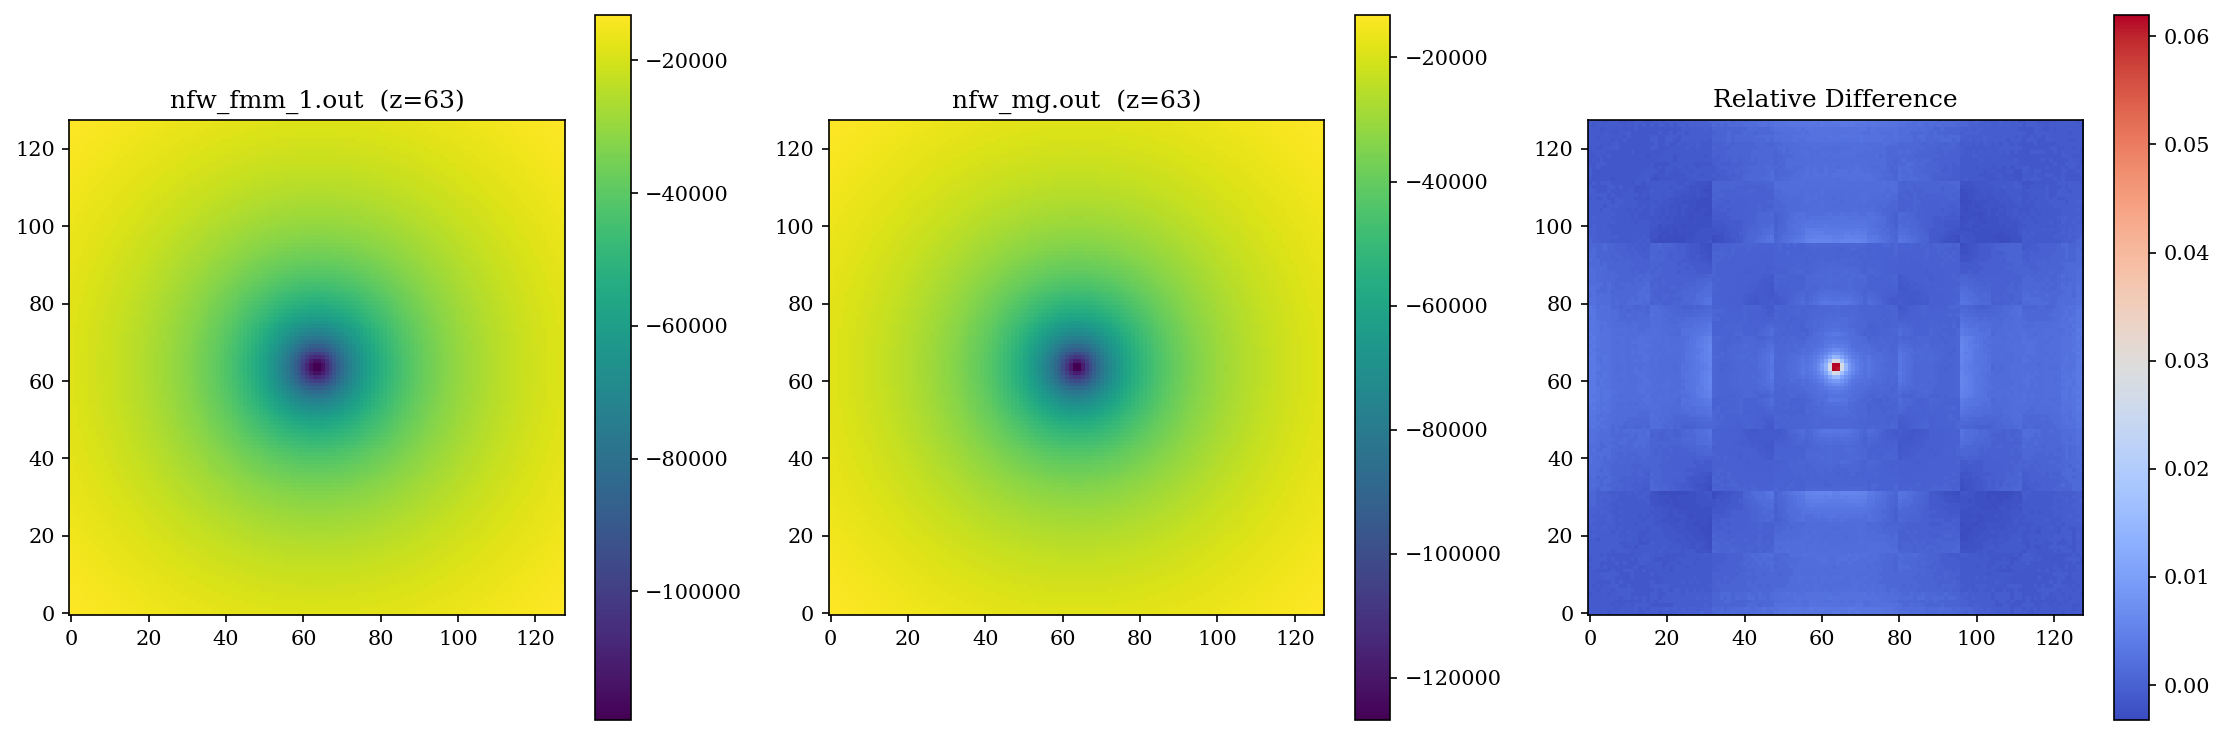

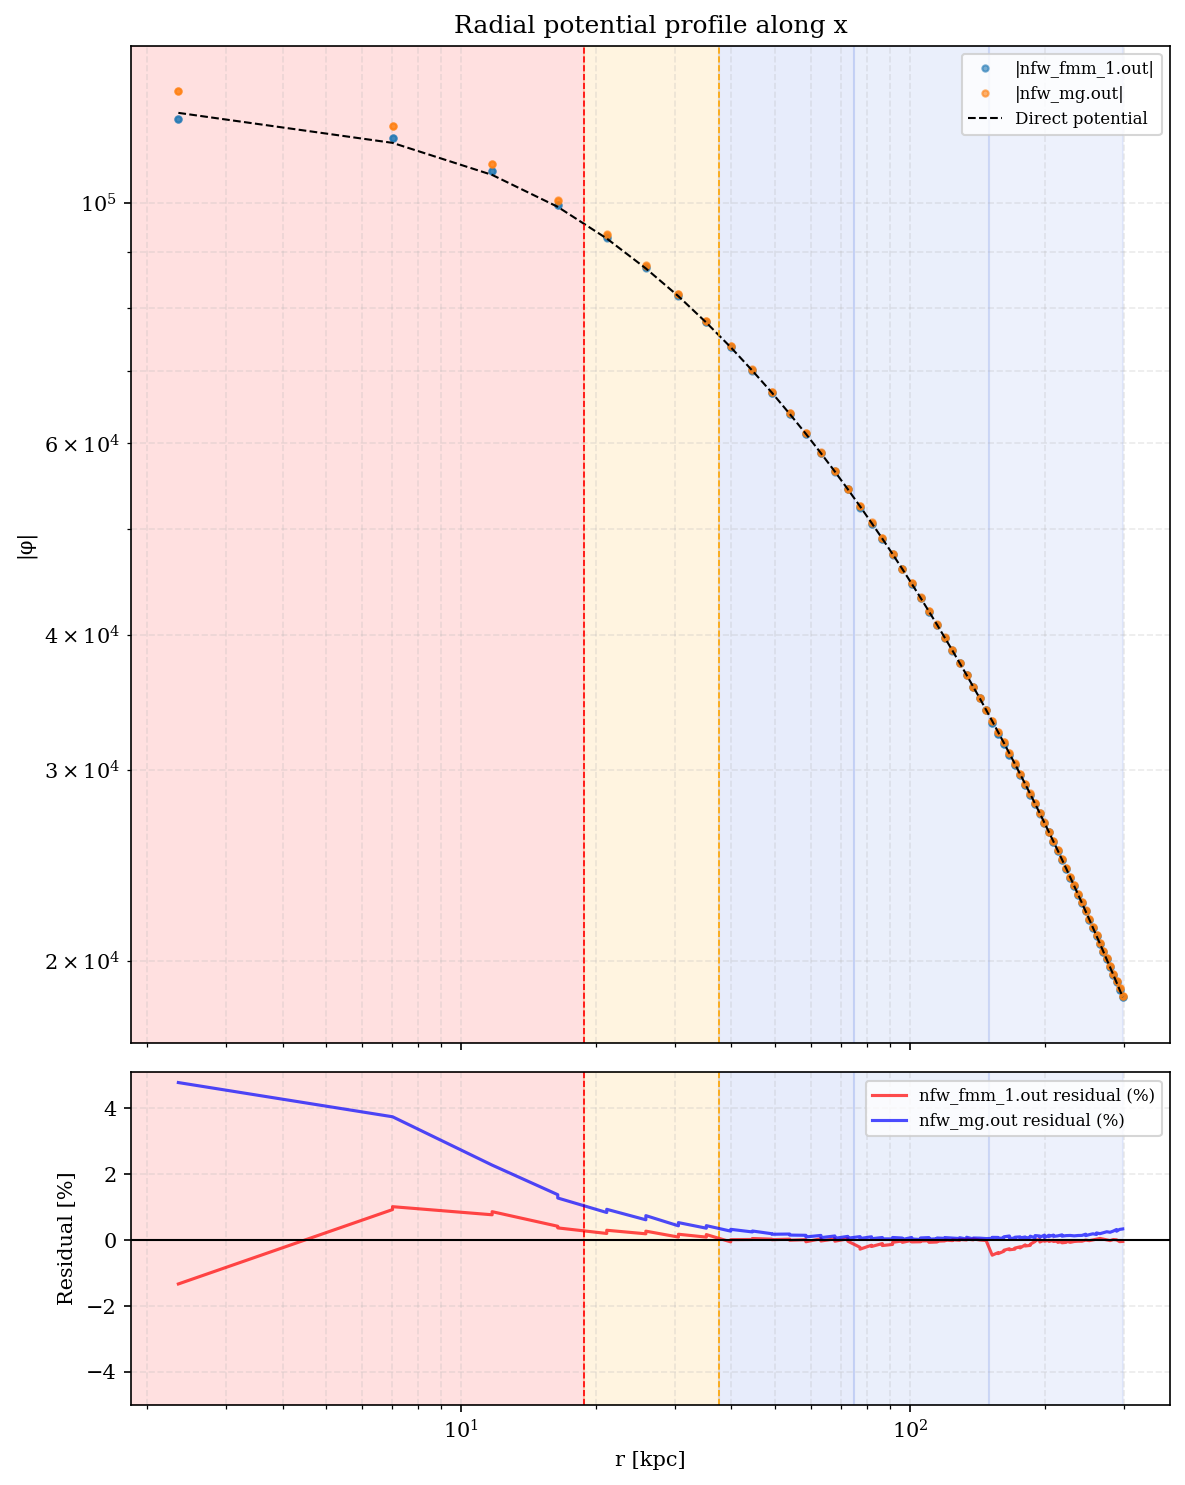

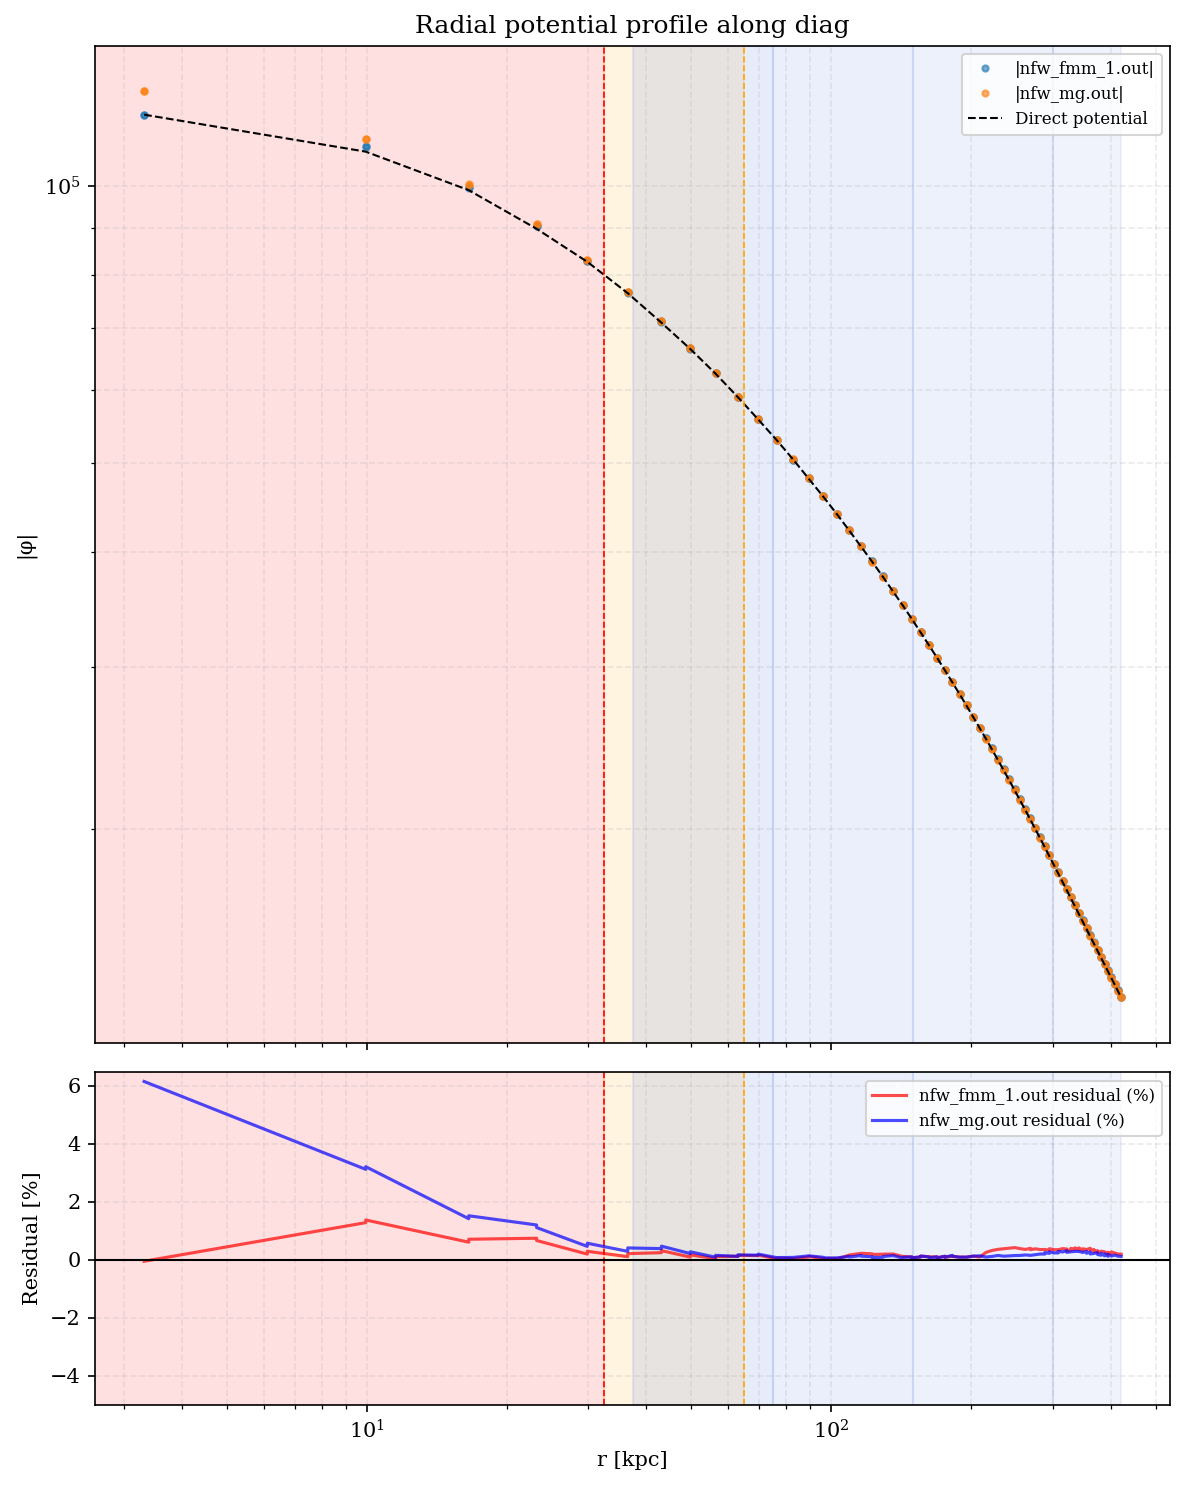

In [120]:
file1 = "nfw_fmm_1.out"
file2 = "nfw_mg.out"  # if filename contains "nfw", overlay NFW analytic
z_slice = 63

df1, df2, label1, label2 = load_data(file1, file2)
plot_2d(df1, df2, label1, label2, z_slice)

# x-direction profile
plot_profile(df1, df2, label1, label2, z_slice, levelmin=7, box_length=600, level_amr_to_fmm=None, mode="x")

# diagonal profile
plot_profile(df1, df2, label1, label2, z_slice, levelmin=7, box_length=600, level_amr_to_fmm=None, mode="diag")


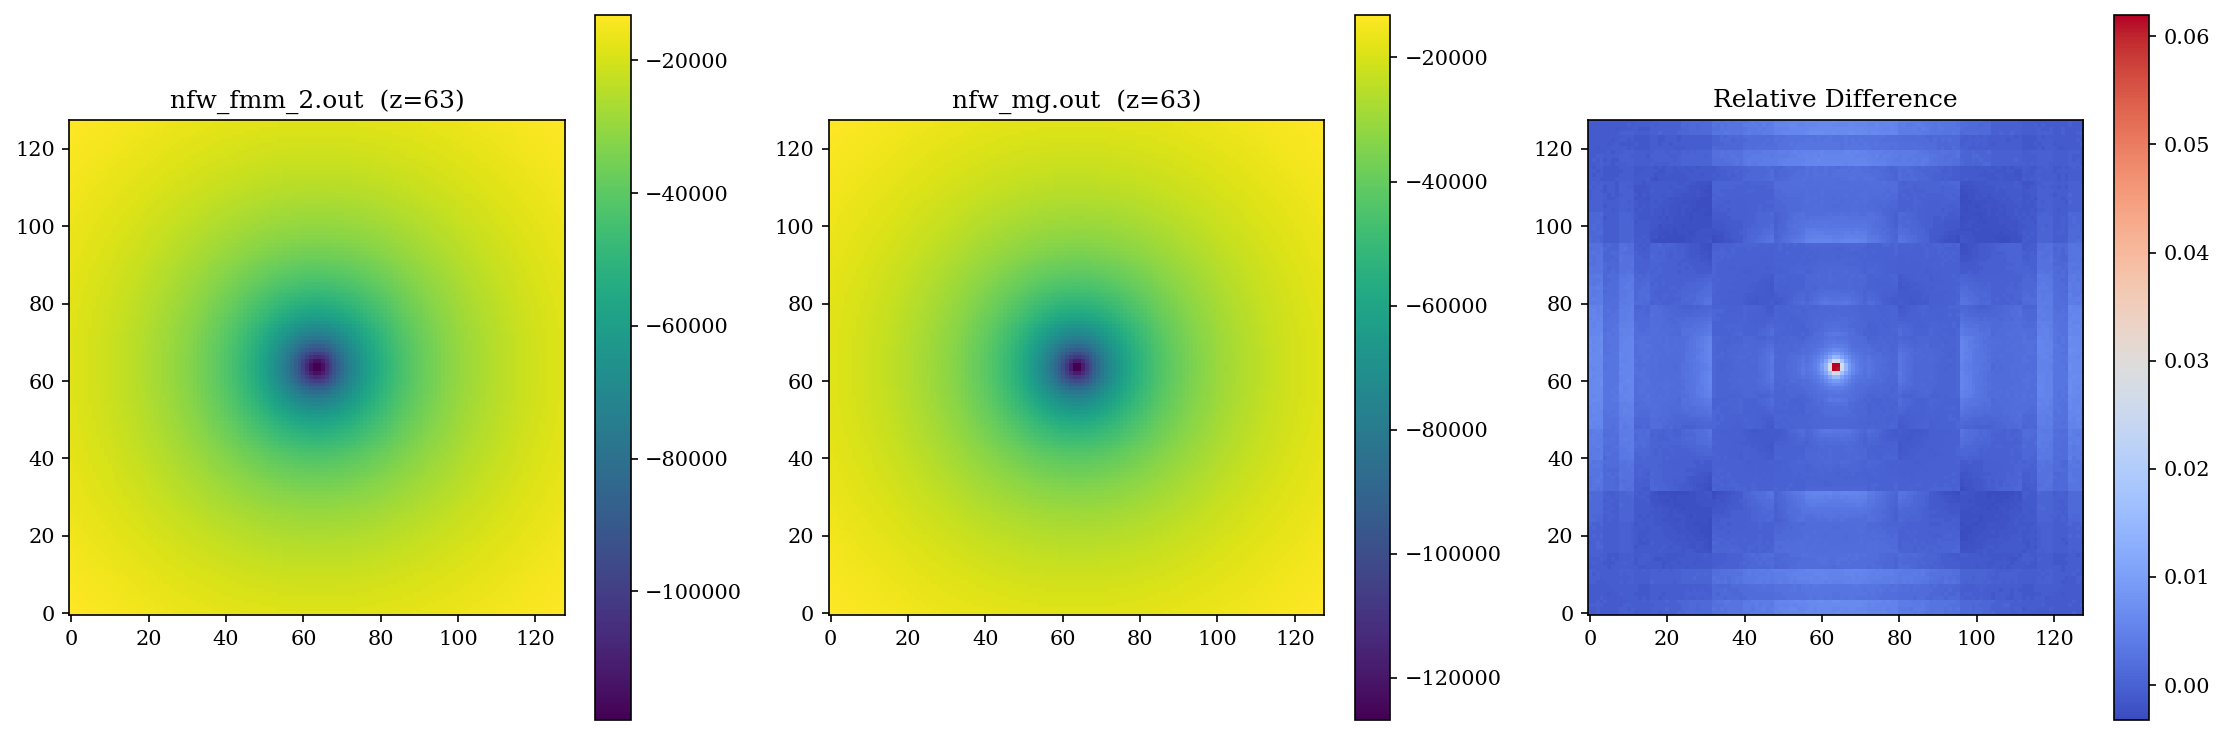

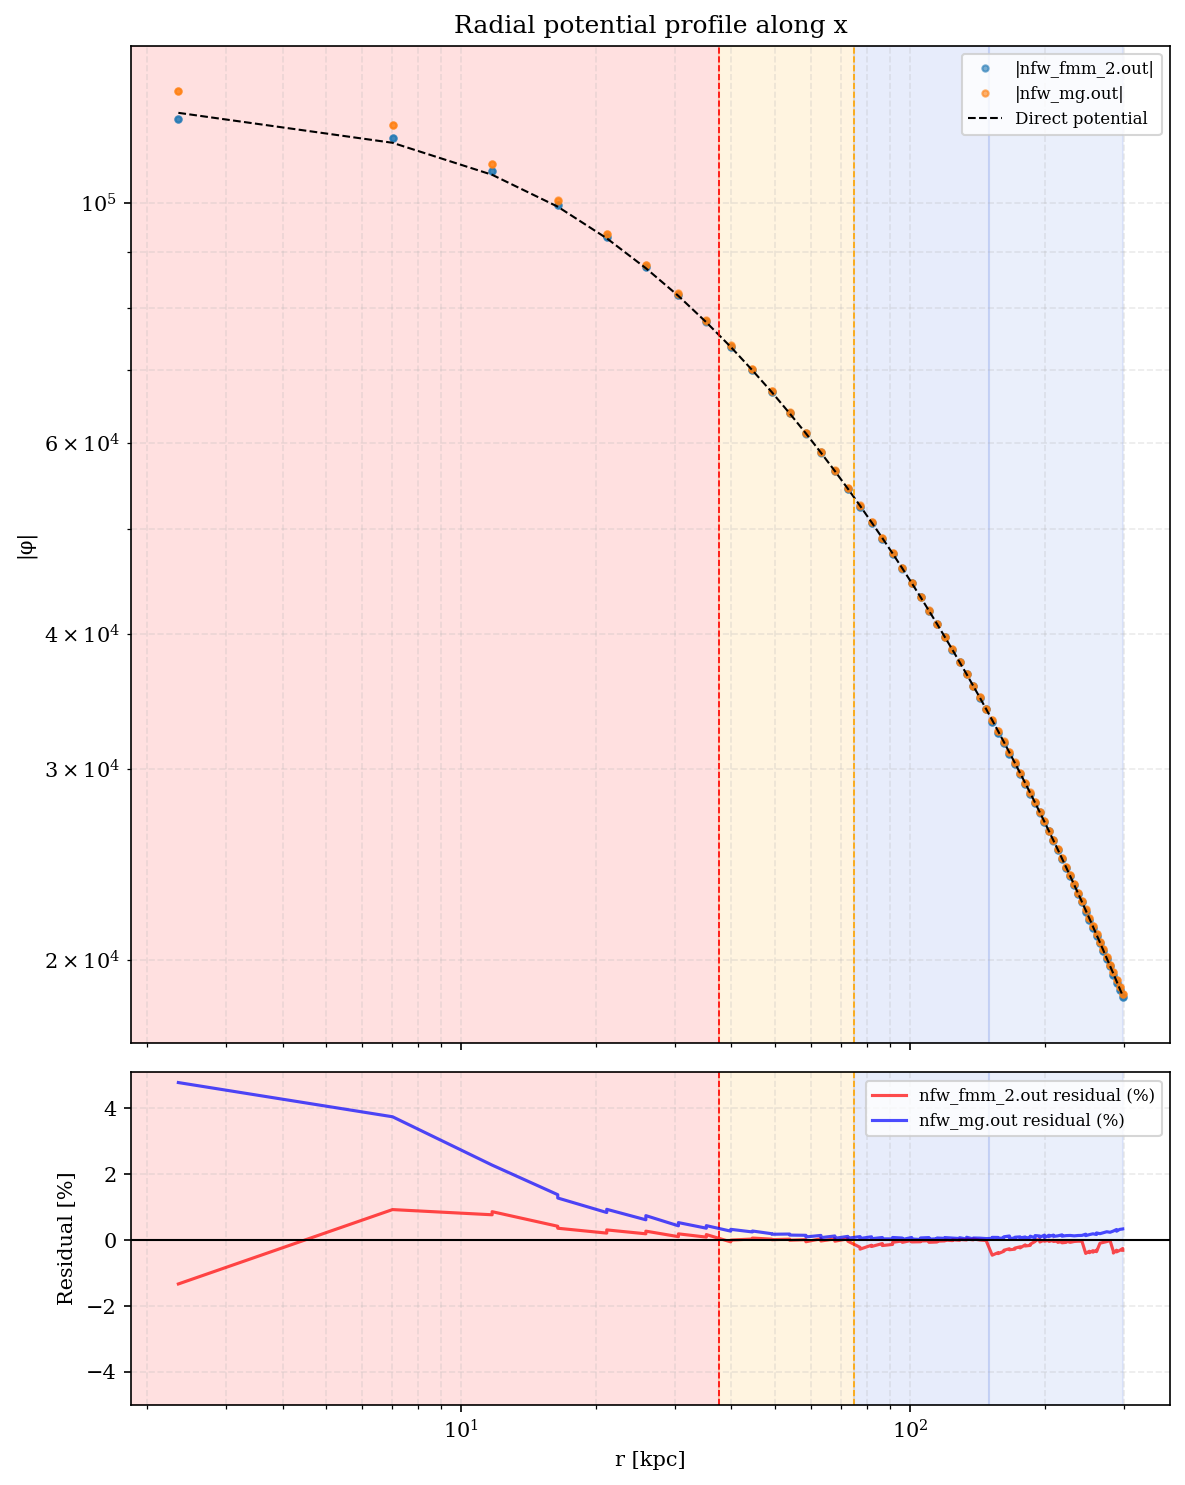

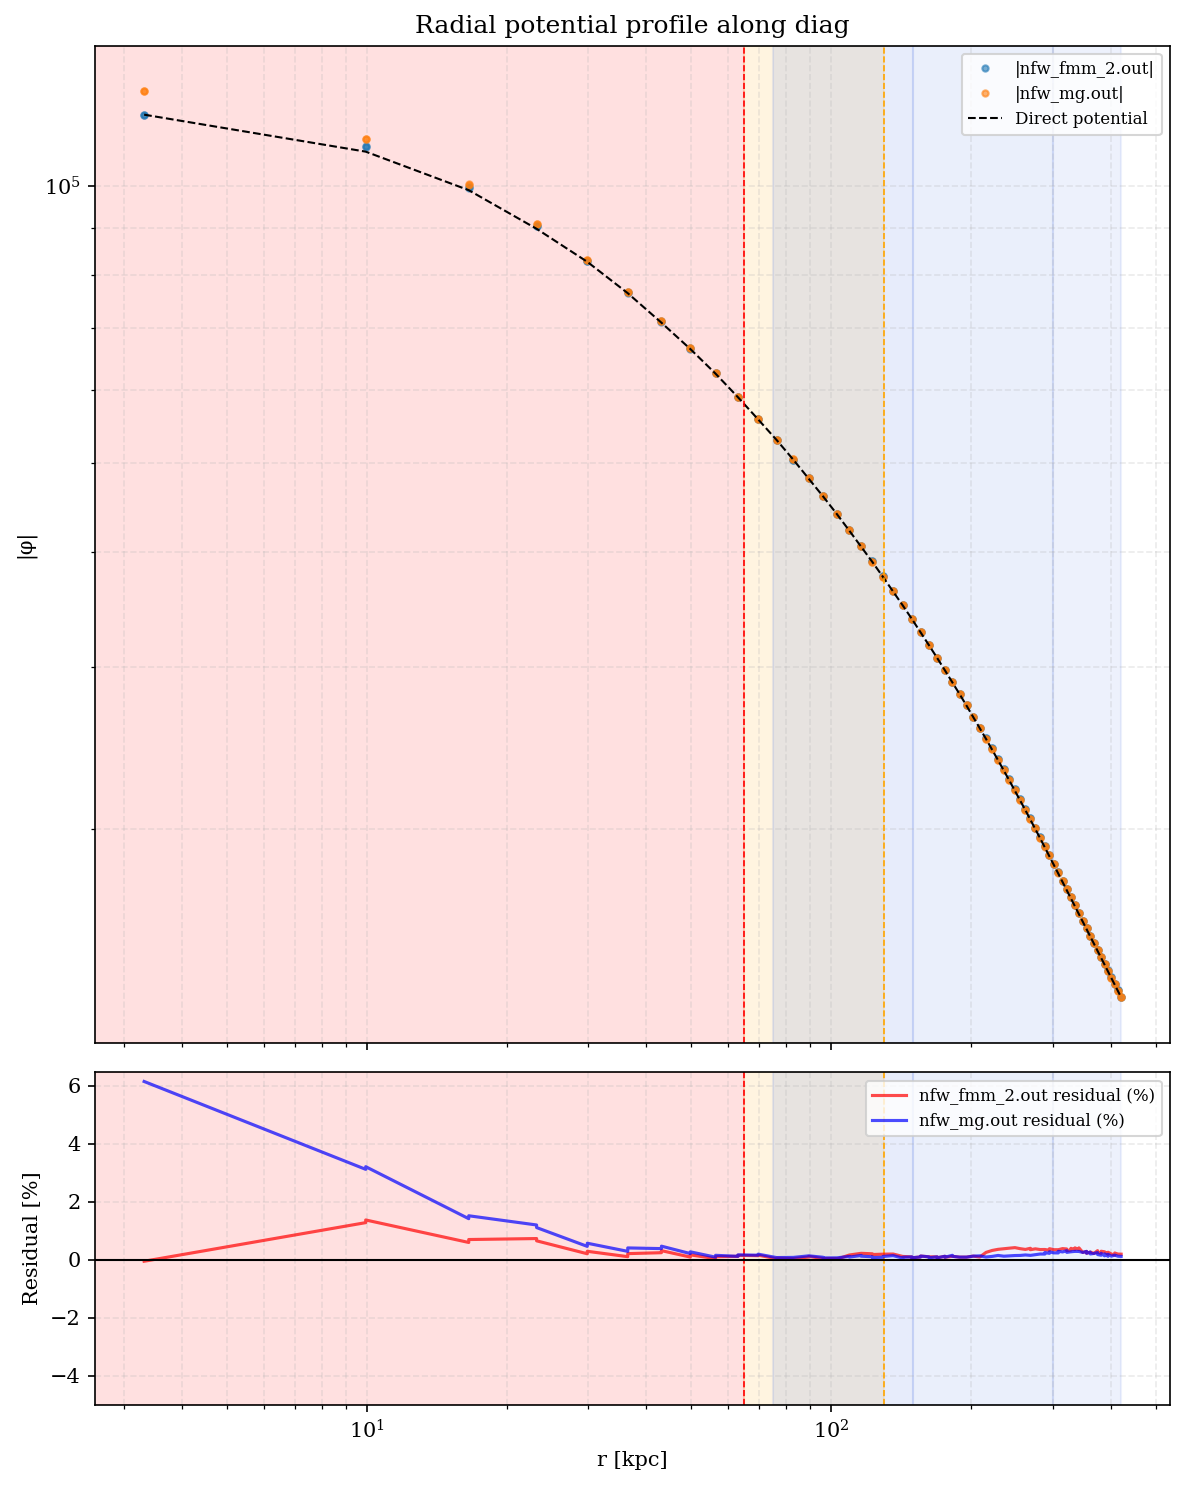

In [121]:
file1 = "nfw_fmm_2.out"
file2 = "nfw_mg.out"  # if filename contains "nfw", overlay NFW analytic
z_slice = 63

df1, df2, label1, label2 = load_data(file1, file2)
plot_2d(df1, df2, label1, label2, z_slice)

# x-direction profile
plot_profile(df1, df2, label1, label2, z_slice, levelmin=7, box_length=600, level_amr_to_fmm=None, mode="x")

# diagonal profile
plot_profile(df1, df2, label1, label2, z_slice, levelmin=7, box_length=600, level_amr_to_fmm=None, mode="diag")


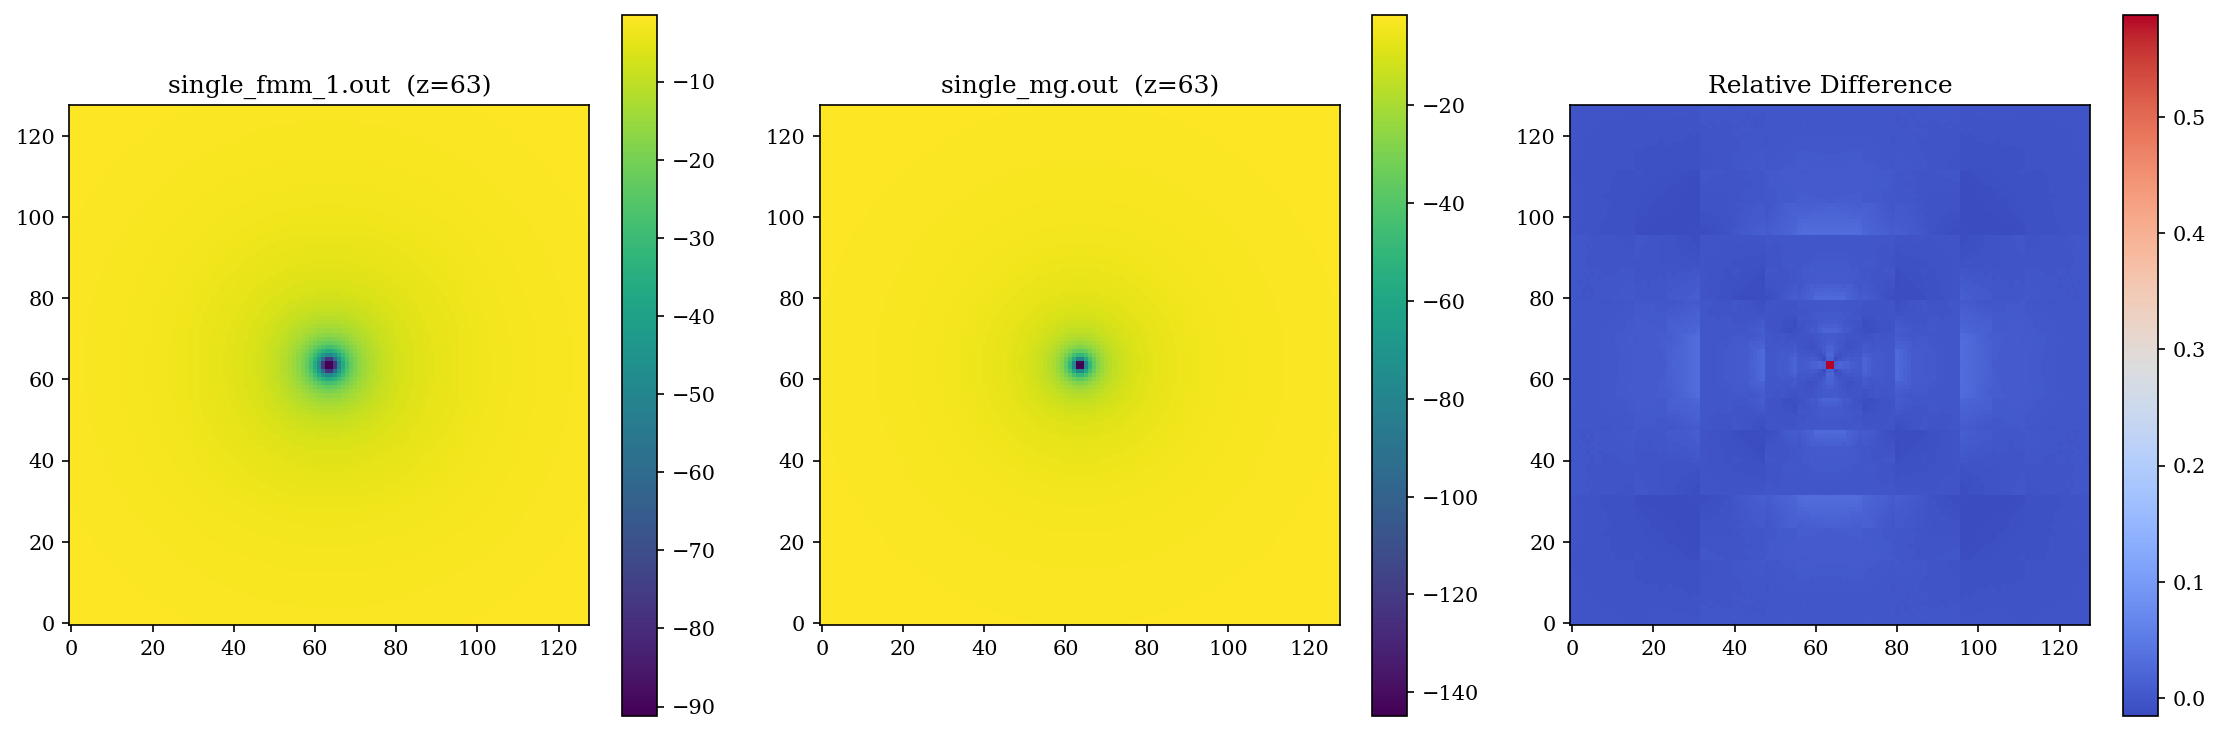

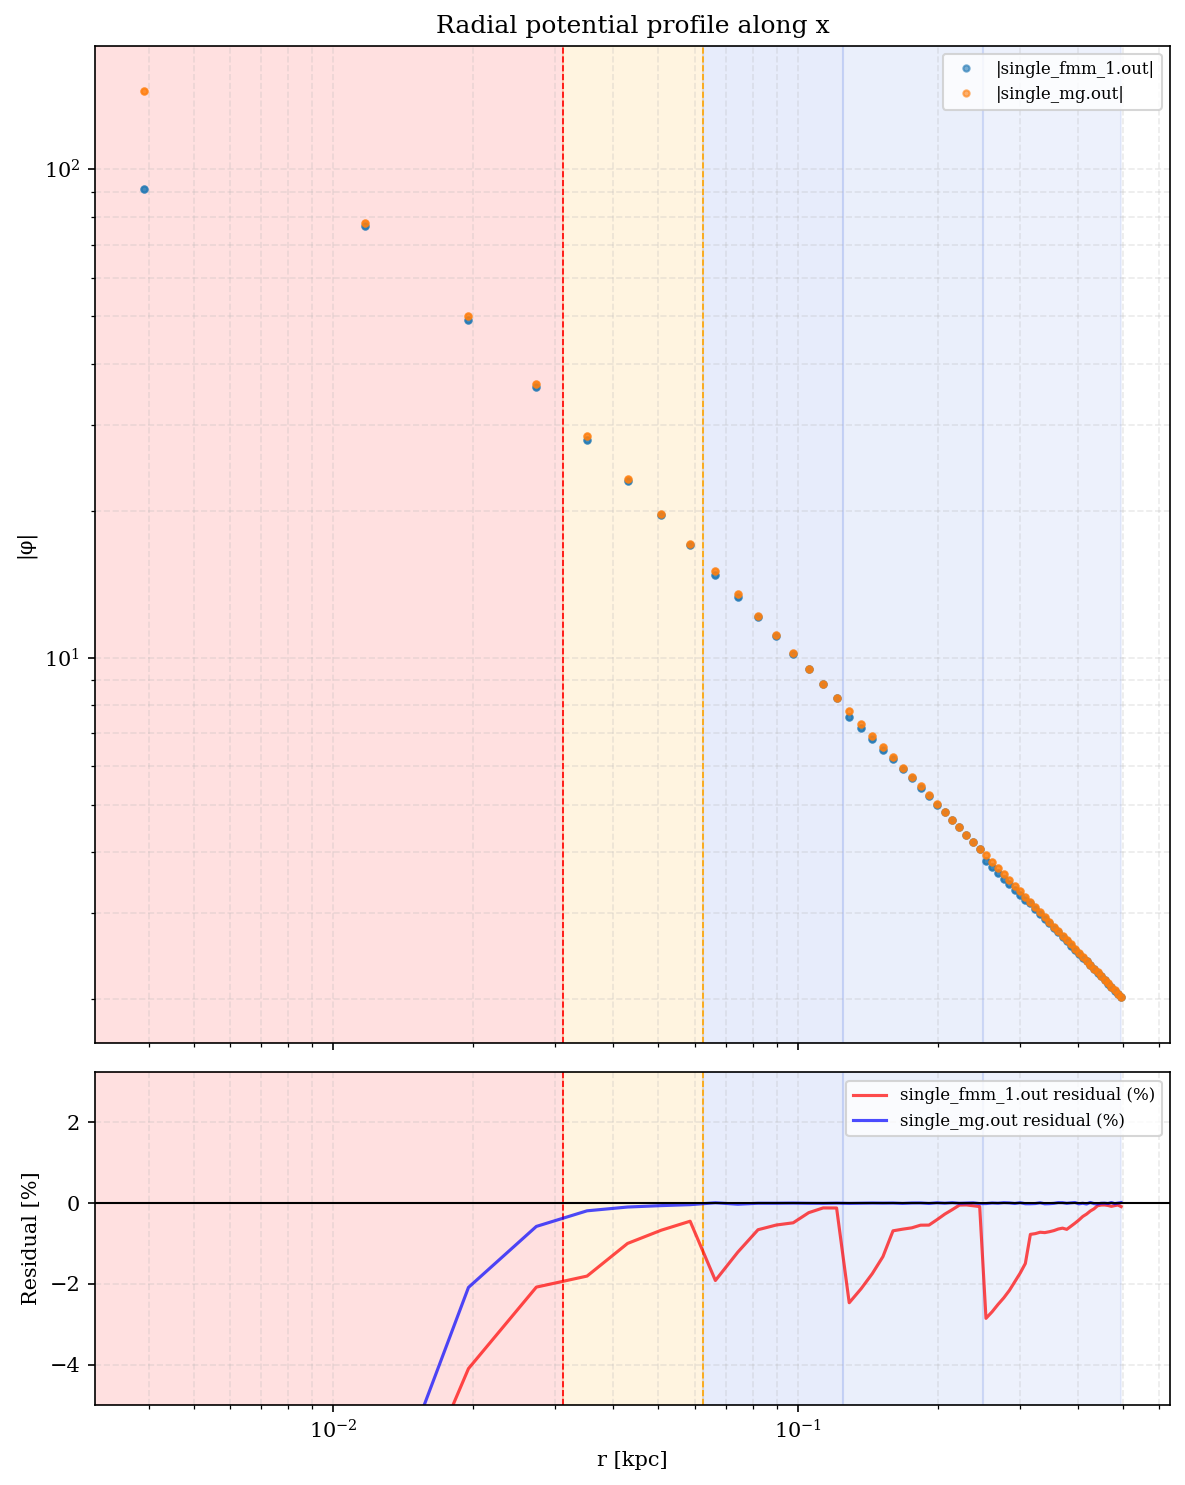

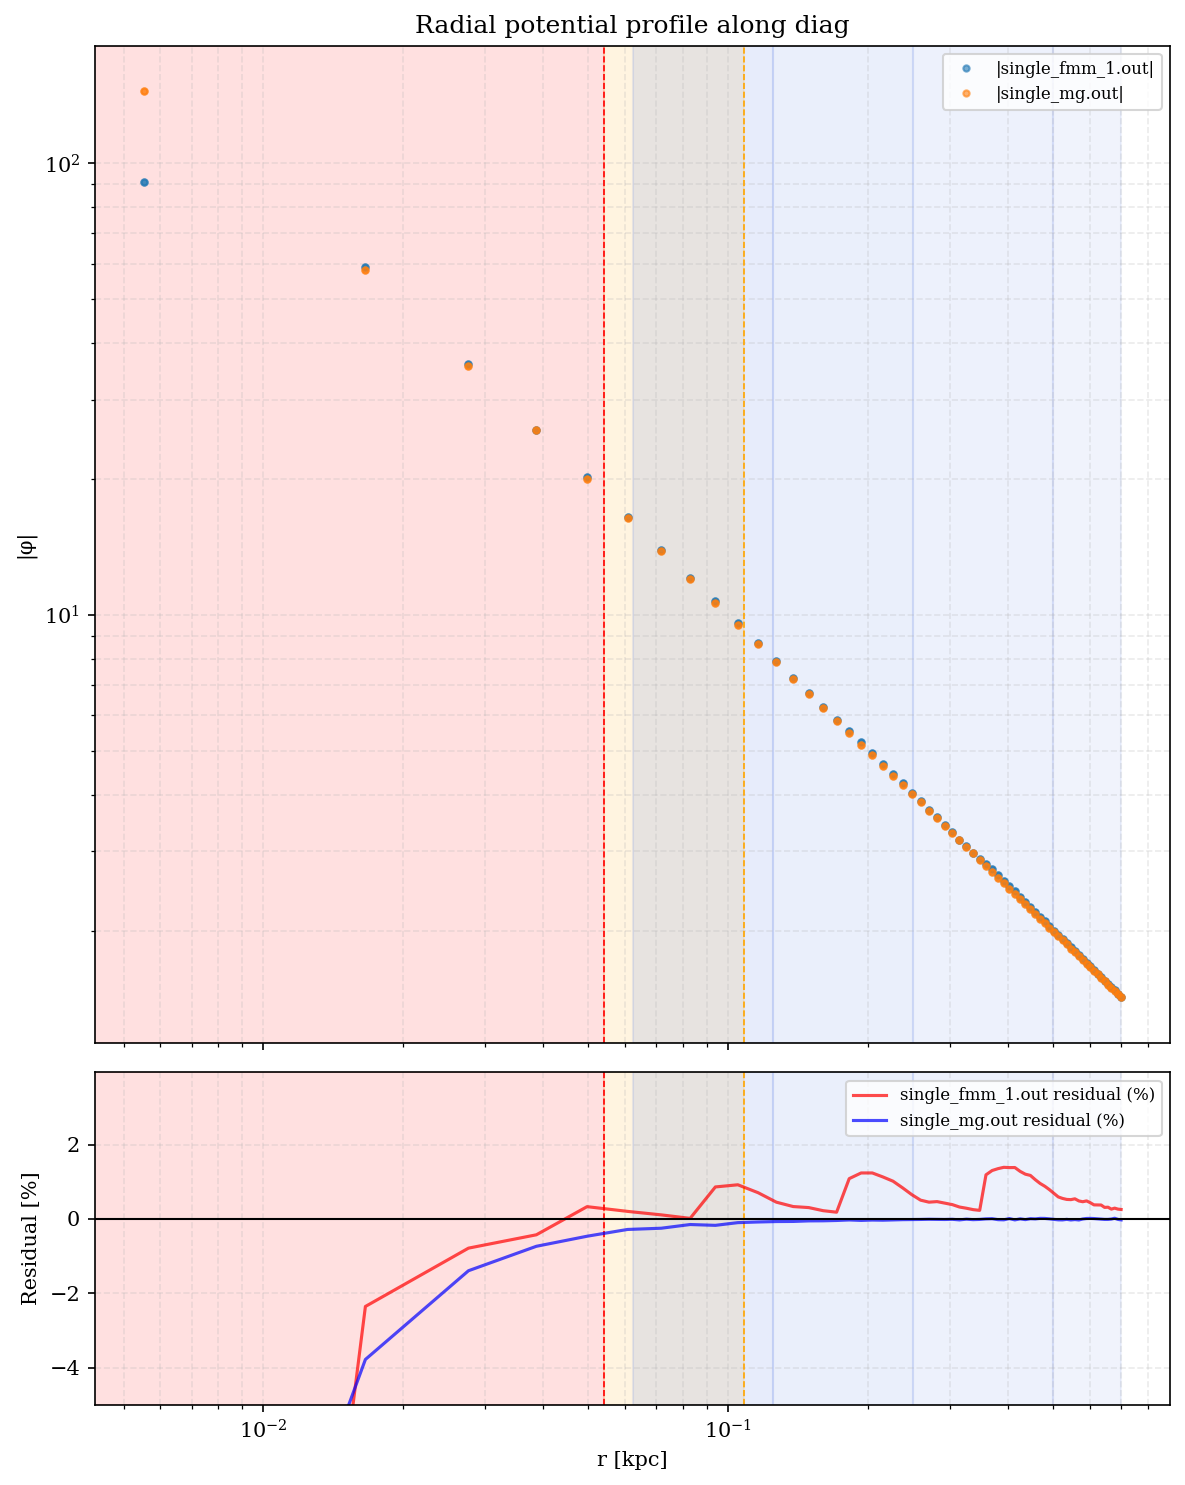

In [122]:
file1 = "single_fmm_1.out"
file2 = "single_mg.out"  # if filename contains "nfw", overlay NFW analytic
z_slice = 63

df1, df2, label1, label2 = load_data(file1, file2)
plot_2d(df1, df2, label1, label2, z_slice)

# x-direction profile
plot_profile(df1, df2, label1, label2, z_slice, levelmin=7, level_amr_to_fmm=None, mode="x")

# diagonal profile
plot_profile(df1, df2, label1, label2, z_slice, levelmin=7, level_amr_to_fmm=None, mode="diag")


In [109]:
# -*- coding: utf-8 -*-
import numpy as np
import os

# -------------------------------
# Parameters
# -------------------------------
ic_file = "../nfw/ic_part"   # columns: x y z vx vy vz m
box_cut = 300.0               # kpc, cube: [-box_cut, box_cut]^3
G = 1.0                       # gravitational constant in kpc (km/s)^2 / Msun
z_cell = 63                    # slice index along z (0..63)
y_cell = 63                    # slice index along y (0..63)
n_points = 64                  # number of x points along x>0
N_cells = 64                   # total number of cells along one axis

# -------------------------------
# Load particle data
# -------------------------------
data = np.loadtxt(ic_file)
x, y, z, vx, vy, vz, m = data.T

# -------------------------------
# Mask particles inside the box
# -------------------------------
mask = (x >= -box_cut) & (x <= box_cut) & \
       (y >= -box_cut) & (y <= box_cut) & \
       (z >= -box_cut) & (z <= box_cut)

x_particles = x[mask]
y_particles = y[mask]
z_particles = z[mask]
m_particles = m[mask]

# -------------------------------
# Cell size and cell-centered positions
# -------------------------------
dx_cell = 2 * box_cut / N_cells   # size of a cell in kpc

# -------------------------------
# Cell-centered x positions from 0 to 63
# -------------------------------
x_eval_cells = np.arange(n_points)   # 0..63
dx_cell = 2 * box_cut / N_cells      # cell size in kpc
x_eval_phys = x_eval_cells * dx_cell + dx_cell/2  # physical center of each cell along x>0
y_eval_phys = 0.5 * dx_cell      # physical y center
z_eval_phys = 0.5 * dx_cell     # physical z center


# -------------------------------
# Direct potential sum along x
# -------------------------------
phi_eval = np.zeros_like(x_eval_phys)

for i, xi in enumerate(x_eval_phys):
    dx = xi - x_particles
    dy = y_eval_phys - y_particles
    dz = z_eval_phys - z_particles
    r = np.sqrt(dx**2 + dy**2 + dz**2)
    r[r == 0] = 1e-10   # avoid division by zero
    phi_eval[i] = - np.sum(G * m_particles / r)

# -------------------------------
# Save to file
# -------------------------------
os.makedirs("./txt", exist_ok=True)
out_file = "./txt/direct_phi_xslice.txt"
np.savetxt(out_file, np.column_stack([x_eval_phys, phi_eval]),
           header="x[kpc]  phi[kpc (km/s)^2]", fmt="%.6e")
print(f"Saved direct potential to {out_file}")

Saved direct potential to ./txt/direct_phi_xslice.txt
